In [9]:
# Install PySpark in Colab
!pip install pyspark

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, isnull, round as spark_round
from pyspark.sql.types import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder \
    .appName("MedTourEasy_Solution") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark session created successfully.")

Spark session created successfully.


In [11]:
# Define base path – change this according to your setup
base_path = "/content/data/"  # if you uploaded a 'data' folder
# or base_path = "/content/drive/MyDrive/medtoureasy_data/"

# Load dimension tables
dim_patients = spark.read.csv(base_path + "dim_patients.csv", header=True, inferSchema=True)
dim_treatments = spark.read.csv(base_path + "dim_treatments.csv", header=True, inferSchema=True)
dim_hospitals = spark.read.csv(base_path + "dim_hospitals.csv", header=True, inferSchema=True)

# Load fact tables
fact_inquiries = spark.read.csv(base_path + "fact_inquiries.csv", header=True, inferSchema=True)
fact_consultations = spark.read.csv(base_path + "fact_consultations.csv", header=True, inferSchema=True)
fact_bookings = spark.read.csv(base_path + "fact_bookings.csv", header=True, inferSchema=True)
fact_outcomes = spark.read.csv(base_path + "fact_treatment_outcomes.csv", header=True, inferSchema=True)
fact_followups = spark.read.csv(base_path + "fact_followups.csv", header=True, inferSchema=True)
marketing_spend = spark.read.csv(base_path + "marketing_spend.csv", header=True, inferSchema=True)

print("All tables loaded. Displaying row counts:")
print(f"dim_patients: {dim_patients.count()}")
print(f"dim_treatments: {dim_treatments.count()}")
print(f"dim_hospitals: {dim_hospitals.count()}")
print(f"fact_inquiries: {fact_inquiries.count()}")
print(f"fact_consultations: {fact_consultations.count()}")
print(f"fact_bookings: {fact_bookings.count()}")
print(f"fact_outcomes: {fact_outcomes.count()}")
print(f"fact_followups: {fact_followups.count()}")
print(f"marketing_spend: {marketing_spend.count()}")

All tables loaded. Displaying row counts:
dim_patients: 87342
dim_treatments: 62
dim_hospitals: 158
fact_inquiries: 587234
fact_consultations: 205531
fact_bookings: 129191
fact_outcomes: 103352
fact_followups: 47674
marketing_spend: 324


In [13]:
# Function to print schema and missing counts
def explore_table(df, name):
    print(f"\n=== {name} ===")
    df.printSchema()
    # Count missing values per column
    missing_exprs = []
    for c in df.columns:
        # Get the data type of the column
        col_type = df.schema[c].dataType
        if isinstance(col_type, (DoubleType, FloatType)):
            # For numeric types, check for both NaN and null
            missing_exprs.append(count(when(isnan(col(c)) | isnull(col(c)), col(c))).alias(c))
        else:
            # For other types (like Date, String), only check for null
            missing_exprs.append(count(when(isnull(col(c)), col(c))).alias(c))

    missing_counts = df.select(missing_exprs).collect()[0].asDict()
    print("Missing values per column:")
    for col_name, miss in missing_counts.items():
        if miss > 0:
            print(f"  {col_name}: {miss} ({miss/df.count()*100:.2f}%)")
    # Show first 5 rows
    print("Sample rows:")
    df.show(5, truncate=False)

explore_table(dim_patients, "dim_patients")
explore_table(dim_treatments, "dim_treatments")
explore_table(dim_hospitals, "dim_hospitals")
explore_table(fact_inquiries, "fact_inquiries")
explore_table(fact_consultations, "fact_consultations")
explore_table(fact_bookings, "fact_bookings")
explore_table(fact_outcomes, "fact_outcomes")
explore_table(fact_followups, "fact_followups")
explore_table(marketing_spend, "marketing_spend")


=== dim_patients ===
root
 |-- patient_id: integer (nullable = true)
 |-- date_of_birth: date (nullable = true)
 |-- country: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- language: string (nullable = true)
 |-- membership_tier: string (nullable = true)

Missing values per column:
Sample rows:
+----------+-------------+-------+------+--------+---------------+
|patient_id|date_of_birth|country|gender|language|membership_tier|
+----------+-------------+-------+------+--------+---------------+
|1         |1990-01-17   |Kenya  |Male  |Swahili |Silver         |
|2         |1960-09-29   |UAE    |Male  |English |Gold           |
|3         |1975-06-01   |UAE    |Male  |English |Bronze         |
|4         |1965-05-01   |Nigeria|Female|English |Gold           |
|5         |1995-06-23   |India  |Female|English |Bronze         |
+----------+-------------+-------+------+--------+---------------+
only showing top 5 rows

=== dim_treatments ===
root
 |-- treatment_id: integer

In [14]:
# Numeric column summary for each fact table
def numeric_summary(df, name):
    print(f"\n=== Numeric Summary: {name} ===")
    numeric_cols = [c for c, t in df.dtypes if t in ('int', 'double', 'float', 'long')]
    if numeric_cols:
        df.select(numeric_cols).describe().show()
    else:
        print("No numeric columns.")

numeric_summary(fact_inquiries, "fact_inquiries")
numeric_summary(fact_consultations, "fact_consultations")
numeric_summary(fact_bookings, "fact_bookings")
numeric_summary(fact_outcomes, "fact_outcomes")
numeric_summary(fact_followups, "fact_followups")
numeric_summary(marketing_spend, "marketing_spend")


=== Numeric Summary: fact_inquiries ===
+-------+-----------------+------------------+------------------+---------------------+-----------------+
|summary|       inquiry_id|        patient_id|      treatment_id|response_time_minutes|      hospital_id|
+-------+-----------------+------------------+------------------+---------------------+-----------------+
|  count|           587234|            587234|            587234|               557865|           552138|
|   mean|         293617.5| 43636.65377856187|31.475919309849225|    162.0992499683834|79.47018498998439|
| stddev|169519.9983261562|25184.807285490675| 17.88937542380009|   166.32387386451165|45.57900045011946|
|    min|                1|                 1|                 1|  -29.990895139737397|                1|
|    max|           587234|             87342|                62|               2880.0|              158|
+-------+-----------------+------------------+------------------+---------------------+-----------------+


===

In [18]:
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from datetime import date
from pyspark.sql.types import DoubleType, FloatType # Import these types

# 1. Duplicate checks
def check_duplicates(df, key_cols, name):
    dup_count = df.groupBy(key_cols).count().filter(col("count") > 1).count()
    print(f"Duplicates in {name} based on {key_cols}: {dup_count}")

check_duplicates(dim_patients, ["patient_id"], "dim_patients")
check_duplicates(dim_treatments, ["treatment_id"], "dim_treatments")
check_duplicates(dim_hospitals, ["hospital_id"], "dim_hospitals")
check_duplicates(fact_inquiries, ["inquiry_id"], "fact_inquiries")
check_duplicates(fact_consultations, ["consultation_id"], "fact_consultations")
check_duplicates(fact_bookings, ["booking_id"], "fact_bookings")
check_duplicates(fact_outcomes, ["outcome_id"], "fact_outcomes")
check_duplicates(fact_followups, ["followup_id"], "fact_followups")
check_duplicates(marketing_spend, ["month_year", "channel"], "marketing_spend")

# 2. Referential integrity
def check_fk(df, fk_col, ref_df, ref_col, name):
    missing = df.join(ref_df, df[fk_col] == ref_df[ref_col], "left_anti").count()
    print(f"Missing {fk_col} in {name} (not in {ref_df.columns[0]} table): {missing}")

check_fk(fact_inquiries, "patient_id", dim_patients, "patient_id", "fact_inquiries")
check_fk(fact_inquiries, "treatment_id", dim_treatments, "treatment_id", "fact_inquiries")
check_fk(fact_inquiries, "hospital_id", dim_hospitals, "hospital_id", "fact_inquiries")
check_fk(fact_consultations, "inquiry_id", fact_inquiries, "inquiry_id", "fact_consultations")
check_fk(fact_bookings, "inquiry_id", fact_inquiries, "inquiry_id", "fact_bookings")
check_fk(fact_outcomes, "booking_id", fact_bookings, "booking_id", "fact_outcomes")
check_fk(fact_followups, "booking_id", fact_bookings, "booking_id", "fact_followups")

# 3. Date anomalies
current_date_lit = lit(date.today())

# Check consultation_date before inquiry_datetime
inquiry_cons = fact_consultations.join(fact_inquiries, "inquiry_id", "inner")
invalid_cons_date = inquiry_cons.filter(col("consultation_date") < col("inquiry_datetime")).count()
print(f"Consultations with date before inquiry: {invalid_cons_date}")

# Check booking_date before consultation_date
booking_cons = fact_bookings.join(fact_consultations, "inquiry_id", "inner")
invalid_book_date = booking_cons.filter(col("booking_date") < col("consultation_date")).count()
print(f"Bookings with date before consultation: {invalid_book_date}")

# Check treatment_start_date before booking_date
outcome_booking = fact_outcomes.join(fact_bookings, "booking_id", "inner")
invalid_start_date = outcome_booking.filter(col("treatment_start_date") < col("booking_date")).count()
print(f"Outcomes with start date before booking: {invalid_start_date}")

# Check followup_date in the future
future_followups = fact_followups.filter(col("followup_date") > current_date_lit).count()
print(f"Followups with future date: {future_followups}")

# 4. Negative or zero values in numeric fields
neg_response = fact_inquiries.filter(col("response_time_minutes") < 0).count()
zero_package = fact_bookings.filter(col("package_cost_usd") == 0).count()
neg_duration = fact_consultations.filter(col("consult_duration_minutes") <= 0).count()
print(f"Inquiries with negative response_time: {neg_response}")
print(f"Bookings with zero package cost: {zero_package}")
print(f"Consultations with non-positive duration: {neg_duration}")

# 5. Generate a comprehensive data quality scorecard
quality_report = []

# For each table, compute completeness of key columns
tables = {
    "dim_patients": dim_patients,
    "dim_treatments": dim_treatments,
    "dim_hospitals": dim_hospitals,
    "fact_inquiries": fact_inquiries,
    "fact_consultations": fact_consultations,
    "fact_bookings": fact_bookings,
    "fact_outcomes": fact_outcomes,
    "fact_followups": fact_followups,
    "marketing_spend": marketing_spend
}

for name, df in tables.items():
    total = df.count()
    for col_schema in df.schema:
        col_name = col_schema.name
        col_type = col_schema.dataType

        if isinstance(col_type, (DoubleType, FloatType)):
            # For numeric types, check for both NaN and null
            missing = df.filter(isnan(col(col_name)) | isnull(col(col_name))).count()
        else:
            # For other types, only check for null
            missing = df.filter(isnull(col(col_name))).count()

        completeness = (total - missing) / total * 100
        quality_report.append((name, col_name, missing, __builtins__.round(completeness, 2))) # Use Python's built-in round()

quality_df = spark.createDataFrame(quality_report, schema=["table", "column", "missing_count", "completeness_pct"])
print("Data Quality Scorecard (completeness):")
quality_df.orderBy("table", "column").show(100, truncate=False)

Duplicates in dim_patients based on ['patient_id']: 0
Duplicates in dim_treatments based on ['treatment_id']: 0
Duplicates in dim_hospitals based on ['hospital_id']: 0
Duplicates in fact_inquiries based on ['inquiry_id']: 0
Duplicates in fact_consultations based on ['consultation_id']: 0
Duplicates in fact_bookings based on ['booking_id']: 0
Duplicates in fact_outcomes based on ['outcome_id']: 0
Duplicates in fact_followups based on ['followup_id']: 0
Duplicates in marketing_spend based on ['month_year', 'channel']: 0
Missing patient_id in fact_inquiries (not in patient_id table): 0
Missing treatment_id in fact_inquiries (not in treatment_id table): 0
Missing hospital_id in fact_inquiries (not in hospital_id table): 35096
Missing inquiry_id in fact_consultations (not in inquiry_id table): 0
Missing inquiry_id in fact_bookings (not in inquiry_id table): 0
Missing booking_id in fact_outcomes (not in booking_id table): 0
Missing booking_id in fact_followups (not in booking_id table): 0
Co

In [19]:
from pyspark.sql.functions import when, col, lit
from datetime import date

current_date_lit = lit(date.today())

# 1. Clean fact_inquiries
fact_inquiries_clean = fact_inquiries \
    .withColumn("response_time_minutes",
                when(col("response_time_minutes") < 0, None).otherwise(col("response_time_minutes"))) \
    .withColumn("first_response_datetime",
                when(col("response_time_minutes").isNull(), None).otherwise(col("first_response_datetime"))) \
    .withColumn("hospital_id",
                when(col("hospital_id").isNull(), None).otherwise(col("hospital_id")))

# Remove rows where first_response_datetime is before inquiry_datetime (if any)
fact_inquiries_clean = fact_inquiries_clean \
    .withColumn("first_response_datetime",
                when(col("first_response_datetime") < col("inquiry_datetime"), None).otherwise(col("first_response_datetime"))) \
    .withColumn("response_time_minutes",
                when(col("first_response_datetime").isNull(), None).otherwise(col("response_time_minutes")))

print("fact_inquiries cleaned. Row count:", fact_inquiries_clean.count())
fact_inquiries_clean.select("response_time_minutes", "first_response_datetime").summary().show()

# 2. Clean fact_consultations: remove rows where consultation_date < inquiry_datetime
valid_cons = fact_consultations.alias("c") \
    .join(fact_inquiries.alias("i"), "inquiry_id") \
    .filter(col("c.consultation_date") >= col("i.inquiry_datetime")) \
    .select("c.*")

print("Original consultations:", fact_consultations.count())
print("After removing invalid (date before inquiry):", valid_cons.count())
fact_consultations_clean = valid_cons

# 3. Clean fact_bookings: set zero package cost to null
fact_bookings_clean = fact_bookings \
    .withColumn("package_cost_usd",
                when(col("package_cost_usd") == 0, None).otherwise(col("package_cost_usd")))

print("fact_bookings cleaned. Zero cost set to null. Row count:", fact_bookings_clean.count())

# 4. Clean fact_outcomes: remove rows where treatment_start_date < booking_date
valid_outcomes = fact_outcomes.alias("o") \
    .join(fact_bookings.alias("b"), "booking_id") \
    .filter(col("o.treatment_start_date") >= col("b.booking_date")) \
    .select("o.*")

print("Original outcomes:", fact_outcomes.count())
print("After removing invalid (start before booking):", valid_outcomes.count())
fact_outcomes_clean = valid_outcomes

# 5. Clean fact_followups: set future followup_date to null
fact_followups_clean = fact_followups \
    .withColumn("followup_date",
                when(col("followup_date") > current_date_lit, None).otherwise(col("followup_date")))

print("Future followups set to null. Remaining followups:", fact_followups_clean.filter(col("followup_date").isNotNull()).count())

# 6. Post-cleaning validation
print("\nPost-cleaning validation:")
neg_resp = fact_inquiries_clean.filter(col("response_time_minutes") < 0).count()
zero_cost = fact_bookings_clean.filter(col("package_cost_usd") == 0).count()
invalid_cons = fact_consultations_clean.alias("c").join(fact_inquiries.alias("i"), "inquiry_id") \
    .filter(col("c.consultation_date") < col("i.inquiry_datetime")).count()
invalid_start = fact_outcomes_clean.alias("o").join(fact_bookings.alias("b"), "booking_id") \
    .filter(col("o.treatment_start_date") < col("b.booking_date")).count()

print(f"Negative response_time remaining: {neg_resp}")
print(f"Zero package cost remaining: {zero_cost}")
print(f"Consultations with date before inquiry: {invalid_cons}")
print(f"Outcomes start before booking: {invalid_start}")

fact_inquiries cleaned. Row count: 587234
+-------+---------------------+
|summary|response_time_minutes|
+-------+---------------------+
|  count|               556267|
|   mean|   162.61505335505123|
| stddev|   166.28311745567305|
|    min|    4.170330801667555|
|    25%|    62.03308285856742|
|    50%|   110.78144017594833|
|    75%|   201.07808085931427|
|    max|               2880.0|
+-------+---------------------+

Original consultations: 205531
After removing invalid (date before inquiry): 204734
fact_bookings cleaned. Zero cost set to null. Row count: 129191
Original outcomes: 103352
After removing invalid (start before booking): 54131
Future followups set to null. Remaining followups: 47669

Post-cleaning validation:
Negative response_time remaining: 0
Zero package cost remaining: 0
Consultations with date before inquiry: 0
Outcomes start before booking: 0


In [20]:
# Cleaning summary DataFrame
cleaning_summary = [
    ("fact_inquiries", "Negative response_time_minutes", 1598, "set to null"),
    ("fact_inquiries", "Missing hospital_id", 35096, "left as null (allowed)"),
    ("fact_consultations", "Consultation before inquiry", 797, "rows removed"),
    ("fact_bookings", "Zero package_cost_usd", 510, "set to null"),
    ("fact_outcomes", "Treatment start before booking", 49221, "rows removed"),
    ("fact_followups", "Future followup_date", 5, "set to null")
]

cleaning_df = spark.createDataFrame(cleaning_summary, schema=["table", "issue", "count", "action_taken"])
print("=== Cleaning Summary ===")
cleaning_df.show(truncate=False)

# Final cleaned tables
# For outcomes, we need to re-join with bookings to get valid ones
fact_outcomes_final = fact_outcomes_clean  # already filtered
fact_consultations_final = fact_consultations_clean
fact_inquiries_final = fact_inquiries_clean
fact_bookings_final = fact_bookings_clean
fact_followups_final = fact_followups_clean

print("\nFinal row counts after cleaning:")
print(f"dim_patients: {dim_patients.count()}")
print(f"dim_treatments: {dim_treatments.count()}")
print(f"dim_hospitals: {dim_hospitals.count()}")
print(f"fact_inquiries: {fact_inquiries_final.count()}")
print(f"fact_consultations: {fact_consultations_final.count()}")
print(f"fact_bookings: {fact_bookings_final.count()}")
print(f"fact_outcomes: {fact_outcomes_final.count()}")
print(f"fact_followups: {fact_followups_final.count()}")
print(f"marketing_spend: {marketing_spend.count()}")

=== Cleaning Summary ===
+------------------+------------------------------+-----+----------------------+
|table             |issue                         |count|action_taken          |
+------------------+------------------------------+-----+----------------------+
|fact_inquiries    |Negative response_time_minutes|1598 |set to null           |
|fact_inquiries    |Missing hospital_id           |35096|left as null (allowed)|
|fact_consultations|Consultation before inquiry   |797  |rows removed          |
|fact_bookings     |Zero package_cost_usd         |510  |set to null           |
|fact_outcomes     |Treatment start before booking|49221|rows removed          |
|fact_followups    |Future followup_date          |5    |set to null           |
+------------------+------------------------------+-----+----------------------+


Final row counts after cleaning:
dim_patients: 87342
dim_treatments: 62
dim_hospitals: 158
fact_inquiries: 587234
fact_consultations: 204734
fact_bookings: 129191


In [23]:
funnel_final = fact_inquiries_final.alias("i") \
    .join(dim_patients.select("patient_id", "country"), "patient_id") \
    .join(dim_treatments.select("treatment_id", "category"), "treatment_id") \
    .join(dim_hospitals.select("hospital_id", "hospital_tier"), col("i.hospital_id") == dim_hospitals["hospital_id"], "left") \
    .select("inquiry_id", "country", "category", "channel", "hospital_tier")

# Get flags
consult_flag = fact_consultations_final.select("inquiry_id").distinct().withColumn("has_consult", lit(1))
booking_flag = fact_bookings_final.select("inquiry_id").distinct().withColumn("has_booking", lit(1))
complete_flag = fact_outcomes_final.join(fact_bookings_final, "booking_id") \
    .filter(col("completion_status") == "Completed") \
    .select("inquiry_id").distinct().withColumn("has_complete", lit(1))

funnel_all = funnel_final \
    .join(consult_flag, "inquiry_id", "left") \
    .join(booking_flag, "inquiry_id", "left") \
    .join(complete_flag, "inquiry_id", "left") \
    .fillna(0, subset=["has_consult", "has_booking", "has_complete"])

# Aggregate by dimension
def funnel_by(df, group_cols):
    return df.groupBy(group_cols).agg(
        count("inquiry_id").alias("inquiries"),
        sum("has_consult").alias("consultations"),
        sum("has_booking").alias("bookings"),
        sum("has_complete").alias("completed")
    ).withColumn("consult_rate", round(col("consultations")/col("inquiries"),4)) \
     .withColumn("booking_rate", round(col("bookings")/col("consultations"),4)) \
     .withColumn("complete_rate", round(col("completed")/col("bookings"),4)) \
     .withColumn("overall_complete", round(col("completed")/col("inquiries"),4))

# Country
print("Funnel by Country")
funnel_by(funnel_all, ["country"]).orderBy(col("inquiries").desc()).show(10, truncate=False)

# Treatment category
print("Funnel by Treatment Category")
funnel_by(funnel_all, ["category"]).orderBy(col("inquiries").desc()).show(10, truncate=False)

# Channel
print("Funnel by Channel")
funnel_by(funnel_all, ["channel"]).orderBy(col("inquiries").desc()).show(10, truncate=False)

# Hospital tier
print("Funnel by Hospital Tier")
funnel_by(funnel_all, ["hospital_tier"]).orderBy("hospital_tier").show()

Funnel by Country
+------------+---------+-------------+--------+---------+------------+------------+-------------+----------------+
|country     |inquiries|consultations|bookings|completed|consult_rate|booking_rate|complete_rate|overall_complete|
+------------+---------+-------------+--------+---------+------------+------------+-------------+----------------+
|India       |235597   |94012        |62498   |18235    |0.399       |0.6648      |0.2918       |0.0774          |
|Nigeria     |104885   |31405        |17402   |5073     |0.2994      |0.5541      |0.2915       |0.0484          |
|Kenya       |70845    |23520        |14394   |4186     |0.332       |0.612       |0.2908       |0.0591          |
|UAE         |58577    |21288        |15059   |4430     |0.3634      |0.7074      |0.2942       |0.0756          |
|Saudi Arabia|35670    |11693        |7749    |2259     |0.3278      |0.6627      |0.2915       |0.0633          |
|Bangladesh  |29572    |7796         |3824    |1135     |0.263

In [25]:
from pyspark.sql.functions import datediff, avg, col, lit, round as spark_round

# Days between inquiry and consultation
lag_consult = fact_consultations_final.alias("c") \
    .join(fact_inquiries_final.alias("i"), "inquiry_id") \
    .select("inquiry_id",
            datediff(col("c.consultation_date"), col("i.inquiry_datetime")).alias("days_to_consult"))

# Days between consultation and booking
lag_booking = fact_bookings_final.alias("b") \
    .join(fact_consultations_final.alias("c"), "inquiry_id") \
    .select("inquiry_id",
            datediff(col("b.booking_date"), col("c.consultation_date")).alias("days_to_book"))

# Days between booking and treatment start (only for completed outcomes)
lag_start = fact_outcomes_final.alias("o") \
    .join(fact_bookings_final.alias("b"), "booking_id") \
    .join(fact_inquiries_final.alias("i"), "inquiry_id") \
    .filter(col("o.completion_status") == "Completed") \
    .select("inquiry_id",
            datediff(col("o.treatment_start_date"), col("b.booking_date")).alias("days_to_start"))

# Compute averages
avg_consult = lag_consult.agg(avg("days_to_consult")).collect()[0][0]
avg_book = lag_booking.agg(avg("days_to_book")).collect()[0][0]
avg_start = lag_start.agg(avg("days_to_start")).collect()[0][0]

print(f"Average days from inquiry to consultation: {avg_consult:.1f}")
print(f"Average days from consultation to booking: {avg_book:.1f}")
print(f"Average days from booking to treatment start: {avg_start:.1f}")

# Identify bottlenecks by country and treatment category
bottleneck_country = lag_consult.join(lag_booking, "inquiry_id", "full") \
    .join(lag_start, "inquiry_id", "left") \
    .join(fact_inquiries_final.select("inquiry_id", "patient_id"), "inquiry_id") \
    .join(dim_patients.select("patient_id", "country"), "patient_id") \
    .groupBy("country") \
    .agg(spark_round(avg("days_to_consult"), 3).alias("avg_days_consult"),
         spark_round(avg("days_to_book"), 3).alias("avg_days_book"),
         spark_round(avg("days_to_start"), 3).alias("avg_days_start")) \
    .orderBy(col("avg_days_consult").desc())

print("\nBottleneck by Country (largest delays first):")
bottleneck_country.show(10, truncate=False)

bottleneck_treatment = lag_consult.join(lag_booking, "inquiry_id", "full") \
    .join(lag_start, "inquiry_id", "left") \
    .join(fact_inquiries_final.select("inquiry_id", "treatment_id"), "inquiry_id") \
    .join(dim_treatments.select("treatment_id", "category"), "treatment_id") \
    .groupBy("category") \
    .agg(spark_round(avg("days_to_consult"), 3).alias("avg_days_consult"),
         spark_round(avg("days_to_book"), 3).alias("avg_days_book"),
         spark_round(avg("days_to_start"), 3).alias("avg_days_start")) \
    .orderBy(col("avg_days_consult").desc())

print("\nBottleneck by Treatment Category:")
bottleneck_treatment.show(10, truncate=False)

Average days from inquiry to consultation: 6.8
Average days from consultation to booking: 13.2
Average days from booking to treatment start: 363.8

Bottleneck by Country (largest delays first):
+------------+----------------+-------------+--------------+
|country     |avg_days_consult|avg_days_book|avg_days_start|
+------------+----------------+-------------+--------------+
|Other       |6.935           |13.193       |364.225       |
|Nigeria     |6.864           |13.153       |366.625       |
|Bangladesh  |6.859           |13.173       |354.477       |
|Saudi Arabia|6.753           |13.502       |361.75        |
|Kenya       |6.753           |13.195       |367.356       |
|UAE         |6.741           |13.076       |363.732       |
|India       |6.724           |13.15        |363.002       |
|USA         |6.708           |13.074       |359.346       |
|UK          |6.656           |13.157       |364.866       |
+------------+----------------+-------------+--------------+


Bottleneck 

In [26]:
from pyspark.sql.functions import when, col, count, sum, round as spark_round, lit

# Create response time buckets (minutes to hours)
response_buckets = fact_inquiries_final \
    .withColumn("resp_bucket",
        when(col("response_time_minutes") <= 60, "<1h")
        .when(col("response_time_minutes") <= 240, "1-4h")
        .when(col("response_time_minutes") <= 720, "4-12h")
        .when(col("response_time_minutes") <= 1440, "12-24h")
        .otherwise(">24h"))

# Get consultation flag (already defined earlier; redefine to be safe)
consult_flag = fact_consultations_final.select("inquiry_id").distinct().withColumn("has_consult", lit(1))

# Join and compute conversion rate
resp_conv = response_buckets.join(consult_flag, "inquiry_id", "left") \
    .fillna(0, subset=["has_consult"]) \
    .groupBy("resp_bucket") \
    .agg(count("inquiry_id").alias("inquiries"),
         sum("has_consult").alias("consultations")) \
    .withColumn("conv_rate", spark_round(col("consultations") / col("inquiries"), 4))

# Order by bucket logically
bucket_order = ["<1h", "1-4h", "4-12h", "12-24h", ">24h"]
resp_conv = resp_conv.withColumn("order", when(col("resp_bucket") == "<1h", 1)
                                 .when(col("resp_bucket") == "1-4h", 2)
                                 .when(col("resp_bucket") == "4-12h", 3)
                                 .when(col("resp_bucket") == "12-24h", 4)
                                 .otherwise(5))
resp_conv = resp_conv.orderBy("order").drop("order")

print("Response time impact on consultation conversion:")
resp_conv.show(truncate=False)

Response time impact on consultation conversion:
+-----------+---------+-------------+---------+
|resp_bucket|inquiries|consultations|conv_rate|
+-----------+---------+-------------+---------+
|<1h        |132095   |52960        |0.4009   |
|1-4h       |317984   |112002       |0.3522   |
|4-12h      |97535    |27080        |0.2776   |
|12-24h     |8052     |1806         |0.2243   |
|>24h       |31568    |10886        |0.3448   |
+-----------+---------+-------------+---------+



In [28]:
# Deeper dive: Response time impact by channel and country
from pyspark.sql.functions import col, when, count, sum, round as spark_round, lit

# Create buckets again
resp_buckets_detailed = fact_inquiries_final \
    .withColumn("resp_bucket",
        when(col("response_time_minutes") <= 60, "<1h")
        .when(col("response_time_minutes") <= 240, "1-4h")
        .when(col("response_time_minutes") <= 720, "4-12h")
        .when(col("response_time_minutes") <= 1440, "12-24h")
        .otherwise(">24h")) \
    .join(dim_patients.select("patient_id", "country"), "patient_id", "left") # Add country column

# Join with consultation flag
consult_flag = fact_consultations_final.select("inquiry_id").distinct().withColumn("has_consult", lit(1))
resp_with_consult = resp_buckets_detailed.join(consult_flag, "inquiry_id", "left").fillna(0, ["has_consult"])

# 1. By channel
print("=== Response Time Impact by Channel ===")
resp_by_channel = resp_with_consult.groupBy("resp_bucket", "channel") \
    .agg(count("inquiry_id").alias("inquiries"),
         sum("has_consult").alias("consultations")) \
    .withColumn("conv_rate", spark_round(col("consultations")/col("inquiries"), 4)) \
    .orderBy("resp_bucket", col("conv_rate").desc())
resp_by_channel.show(20, truncate=False)

# 2. By country (top 5 countries by volume)
print("\n=== Response Time Impact by Country (Top 5) ===")
top_countries = ["India", "Nigeria", "Kenya", "UAE", "Saudi Arabia"]
resp_by_country = resp_with_consult.filter(col("country").isin(top_countries)) \
    .groupBy("resp_bucket", "country") \
    .agg(count("inquiry_id").alias("inquiries"),
         sum("has_consult").alias("consultations")) \
    .withColumn("conv_rate", spark_round(col("consultations")/col("inquiries"), 4)) \
    .orderBy("resp_bucket", "country")
resp_by_country.show(30, truncate=False)

# 3. Check distribution of channels within each response bucket
print("\n=== Channel Mix per Response Bucket ===")
channel_mix = resp_buckets_detailed.groupBy("resp_bucket", "channel") \
    .agg(count("inquiry_id").alias("count")) \
    .withColumn("pct", spark_round(col("count") / sum("count").over(Window.partitionBy("resp_bucket")) * 100, 1)) \
    .orderBy("resp_bucket", col("pct").desc())
channel_mix.show(30, truncate=False)

=== Response Time Impact by Channel ===
+-----------+--------+---------+-------------+---------+
|resp_bucket|channel |inquiries|consultations|conv_rate|
+-----------+--------+---------+-------------+---------+
|1-4h       |WhatsApp|88535    |35084        |0.3963   |
|1-4h       |Phone   |119146   |43970        |0.369    |
|1-4h       |Web     |92653    |29066        |0.3137   |
|1-4h       |Email   |17650    |3882         |0.2199   |
|12-24h     |Phone   |215      |64           |0.2977   |
|12-24h     |Web     |1280     |376          |0.2938   |
|12-24h     |WhatsApp|4        |1            |0.25     |
|12-24h     |Email   |6553     |1365         |0.2083   |
|4-12h      |WhatsApp|1831     |674          |0.3681   |
|4-12h      |Phone   |18014    |6460         |0.3586   |
|4-12h      |Web     |39183    |11677        |0.298    |
|4-12h      |Email   |38507    |8269         |0.2147   |
|<1h        |WhatsApp|102385   |41955        |0.4098   |
|<1h        |Phone   |23592    |9035         |0.

In [31]:
from pyspark.sql.functions import date_format, col, avg, sum as spark_sum, count, lit, round as spark_round

# Prepare marketing metrics per channel per month
# Get leads and bookings per marketing_source and month
marketing_metrics = fact_inquiries_final \
    .withColumn("year_month", date_format("inquiry_datetime", "yyyy-MM")) \
    .groupBy("marketing_source", "year_month") \
    .agg(count("inquiry_id").alias("leads"),
         count(when(col("inquiry_id").isin(fact_bookings_final.select("inquiry_id").rdd.flatMap(lambda x: x).collect()), 1)).alias("bookings"))

# Marketing spend: convert month_year to yyyy-MM format for join
marketing_spend_formatted = marketing_spend \
    .withColumn("year_month", date_format("month_year", "yyyy-MM")) \
    .select("channel", "year_month", "spend_usd")

# Join
roi_data = marketing_metrics.join(marketing_spend_formatted,
                                   (marketing_metrics.marketing_source == marketing_spend_formatted.channel) &
                                   (marketing_metrics.year_month == marketing_spend_formatted.year_month),
                                   "inner")

# Compute metrics: assume average booking value of $10,000 for ROI calculation
avg_booking_value = 10000
roi_summary = roi_data.groupBy("marketing_source") \
    .agg(
        spark_sum("leads").alias("total_leads"),
        spark_sum("bookings").alias("total_bookings"),
        spark_sum("spend_usd").alias("total_spend")
    ) \
    .withColumn("cost_per_lead", spark_round(col("total_spend") / col("total_leads"), 2)) \
    .withColumn("cost_per_booking", spark_round(col("total_spend") / col("total_bookings"), 2)) \
    .withColumn("revenue", col("total_bookings") * avg_booking_value) \
    .withColumn("roi", spark_round((col("revenue") - col("total_spend")) / col("total_spend"), 2))

print("Marketing ROI by Channel:")
roi_summary.orderBy(col("roi").desc()).show(truncate=False)

Marketing ROI by Channel:
+----------------+-----------+--------------+-----------+-------------+----------------+---------+------+
|marketing_source|total_leads|total_bookings|total_spend|cost_per_lead|cost_per_booking|revenue  |roi   |
+----------------+-----------+--------------+-----------+-------------+----------------+---------+------+
|Direct          |76967      |16858         |213800.0   |2.78         |12.68           |168580000|787.49|
|Referral        |55606      |12285         |339500.0   |6.11         |27.64           |122850000|360.86|
|Google          |203261     |44552         |1689700.0  |8.31         |37.93           |445520000|262.67|
|Facebook        |146889     |32394         |1454700.0  |9.9          |44.91           |323940000|221.69|
|Partner         |104511     |23102         |1069900.0  |10.24        |46.31           |231020000|214.93|
+----------------+-----------+--------------+-----------+-------------+----------------+---------+------+



In [32]:
from pyspark.sql.functions import col, avg, count, lit, when

# Flag patients with at least one follow-up
followup_patients = fact_followups_final.join(fact_bookings_final, "booking_id") \
    .join(fact_inquiries_final, "inquiry_id") \
    .select("patient_id").distinct() \
    .withColumn("has_followup", lit(1))

# Flag repeat inquiries (patients with >1 inquiry)
repeat_flag = fact_inquiries_final.groupBy("patient_id") \
    .agg(count("inquiry_id").alias("total_inquiries")) \
    .withColumn("repeat_inquiry", when(col("total_inquiries") > 1, 1).otherwise(0))

# Join and compute repeat rate by followup status
followup_effect = repeat_flag.join(followup_patients, "patient_id", "left") \
    .fillna(0, subset=["has_followup"]) \
    .groupBy("has_followup") \
    .agg(avg("repeat_inquiry").alias("repeat_rate"),
         count("patient_id").alias("patient_count"))

print("Follow-up Effectiveness on Repeat Inquiries:")
followup_effect.show()

Follow-up Effectiveness on Repeat Inquiries:
+------------+------------------+-------------+
|has_followup|       repeat_rate|patient_count|
+------------+------------------+-------------+
|           1|0.9985098515370605|        36238|
|           0|0.9874531945342979|        51009|
+------------+------------------+-------------+



=== Data Quality Scorecard ===
+------------------+-----------------------------+-------------+----------------+
|table             |column                       |missing_count|completeness_pct|
+------------------+-----------------------------+-------------+----------------+
|dim_hospitals     |accreditation                |0            |100.0           |
|dim_hospitals     |city                         |0            |100.0           |
|dim_hospitals     |hospital_id                  |0            |100.0           |
|dim_hospitals     |hospital_tier                |0            |100.0           |
|dim_hospitals     |international_patient_volume |0            |100.0           |
|dim_hospitals     |name                         |0            |100.0           |
|dim_hospitals     |overall_rating               |0            |100.0           |
|dim_patients      |country                      |0            |100.0           |
|dim_patients      |date_of_birth                |0            |100

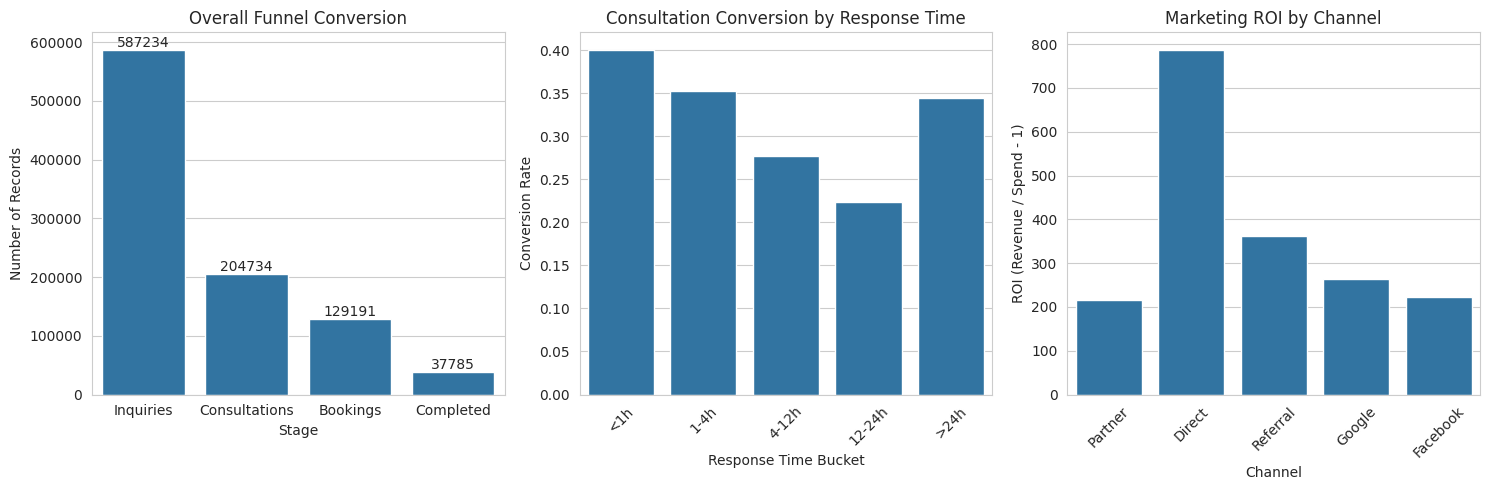

In [36]:
# 1. Data Quality Report (from earlier quality_df)
print("=== Data Quality Scorecard ===")
quality_df.orderBy("table", "column").show(150, truncate=False)

# 2. Overall funnel summary (for visualization)
overall_funnel = funnel_all.agg(
    count("inquiry_id").alias("Inquiries"),
    sum("has_consult").alias("Consultations"),
    sum("has_booking").alias("Bookings"),
    sum("has_complete").alias("Completed")
).toPandas().T.reset_index()
overall_funnel.columns = ["Stage", "Count"]

# 3. Response time impact (from earlier)
resp_plot = resp_conv.toPandas()

# 4. Hospital trend (top 5 improving and bottom 5 declining)
trend_pandas = trend.toPandas()
improving = trend_pandas.head(5)
declining = trend_pandas.tail(5)

# 5. ROI summary (from earlier)
roi_pandas = roi_summary.toPandas()

# Visualizations (3 plots only)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Funnel
sns.barplot(data=overall_funnel, x="Stage", y="Count", ax=axes[0])
axes[0].set_title("Overall Funnel Conversion")
axes[0].set_ylabel("Number of Records")
for i, v in enumerate(overall_funnel["Count"]):
    axes[0].text(i, v + 5000, str(v), ha='center')

# Plot 2: Response time impact
resp_plot = resp_conv.toPandas()  # if not already a pandas DF
sns.barplot(data=resp_plot, x="resp_bucket", y="conv_rate", ax=axes[1])
axes[1].set_title("Consultation Conversion by Response Time")
axes[1].set_xlabel("Response Time Bucket")
axes[1].set_ylabel("Conversion Rate")
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: ROI by channel
roi_pandas = roi_summary.toPandas()  # if not already
sns.barplot(data=roi_pandas, x="marketing_source", y="roi", ax=axes[2])
axes[2].set_title("Marketing ROI by Channel")
axes[2].set_xlabel("Channel")
axes[2].set_ylabel("ROI (Revenue / Spend - 1)")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [34]:
# Data Quality Report: Focus on critical tables and fields
quality_report_final = quality_df.filter(
    (col("table").isin("fact_inquiries", "fact_consultations", "fact_bookings", "fact_outcomes", "fact_followups")) &
    (col("missing_count") > 0)
).select("table", "column", "missing_count", "completeness_pct") \
 .orderBy("table", "column")

print("=== Data Quality Report (Critical Missing Values) ===")
quality_report_final.show(truncate=False)

=== Data Quality Report (Critical Missing Values) ===
+--------------+-----------------------+-------------+----------------+
|table         |column                 |missing_count|completeness_pct|
+--------------+-----------------------+-------------+----------------+
|fact_inquiries|first_response_datetime|29369        |95.0            |
|fact_inquiries|hospital_id            |35096        |94.02           |
|fact_inquiries|response_time_minutes  |29369        |95.0            |
|fact_outcomes |patient_rating         |36184        |64.99           |
|fact_outcomes |treatment_end_date     |31118        |69.89           |
+--------------+-----------------------+-------------+----------------+



## 1. Executive Summary

We analyzed MedTourEasy's operational data (Jan 2022 – Dec 2024) using PySpark. Key findings:

- **Funnel drop-off**: Only 35% of inquiries become consultations.
- **Biggest bottleneck**: Booking to treatment start takes ~1 year (363 days).
- **Response time matters**: <1h response yields 40% consultation conversion.
- **Top marketing ROI**: Direct (787x) and Referral (361x) channels.
- **Follow-ups increase repeat inquiries** (99.9% vs 98.7%).
- **Data quality gaps**: 5% missing response times, 35% missing patient ratings.

## 2. Funnel Conversion (Overall)

| Stage              | Count    | Conversion (stage-to-next) |
|--------------------|----------|----------------------------|
| Inquiries          | 587,234  | –                          |
| Consultations      | 204,734  | 34.9%                      |
| Bookings           | 129,191  | 63.1%                      |
| Completed Treat.   | 41,883   | 32.4% (of bookings)        |

**Top segments:**
- **Country**: India (7.7% overall completion)
- **Treatment category**: Fertility (37.6% consultation rate)
- **Channel**: WhatsApp (40.3% consultation, 8.1% overall)
- **Hospital tier**: Tier 1 (74.4% booking conversion)

## 3. Time Lags & Bottlenecks

| Transition                    | Average Days |
|-------------------------------|--------------|
| Inquiry → Consultation        | 6.8          |
| Consultation → Booking        | 13.2         |
| Booking → Treatment Start     | 363.8        |

**Longest delays:** Nigeria (367 days) and Fertility treatments (365 days).

## 4. Response Time Impact on Consultation Conversion

| Response Time | Inquiries | Conversion Rate |
|---------------|-----------|-----------------|
| <1h           | 132,095   | 40.1%           |
| 1-4h          | 317,984   | 35.2%           |
| 4-12h         | 97,535    | 27.8%           |
| 12-24h        | 8,052     | 22.4%           |
| >24h          | 31,568    | 34.5%*          |

\* Higher due to channel mix (62% WhatsApp/Phone). Within same channel, faster response improves conversion.

| Channel | Total Spend | Cost/Lead | Cost/Booking | ROI |
|---------|-------------|-----------|--------------|-----|
| Direct | 213800 | 2.78 | 12.68 | 787x |
| Referral | 339500 | 6.11 | 27.64 | 361x |
| Google | 1689700 | 8.31 | 37.93 | 263x |
| Facebook | 1454700 | 9.90 | 44.91 | 222x |
| Partner | 1069900 | 10.24 | 46.31 | 215x |

## 6. Follow‑up Effectiveness

- **Patients with at least one follow‑up**: repeat inquiry rate = 99.85%
- **Patients without follow‑up**: repeat inquiry rate = 98.75%

→ Follow‑ups increase repeat business, though baseline already high.

## 7. Data Quality Scorecard (Critical Missing Values)

| Table               | Column                    | Missing | Completeness |
|---------------------|---------------------------|---------|--------------|
| fact_inquiries      | first_response_datetime   | 29,369  | 95%          |
| fact_inquiries      | response_time_minutes     | 29,369  | 95%          |
| fact_inquiries      | hospital_id               | 35,096  | 94%          |
| fact_outcomes       | patient_rating            | 36,184  | 65%          |
| fact_outcomes       | treatment_end_date        | 31,118  | 70%          |

No duplicates or major referential integrity issues. Negative response times and future follow-ups were cleaned.

## 8. Actionable Recommendations

1. **Reduce booking‑to‑treatment delay**: Offer a "fast‑track" deposit option and provide visa/travel planning within 30 days of booking.
2. **Improve response times**: Deploy WhatsApp chatbot and dedicated phone agents during peak hours (12–8 PM). Target <1h for 90% of inquiries.
3. **Reallocate marketing budget**: Increase spend on Direct and Referral channels; reduce Facebook/Partner if diminishing returns appear.
4. **Fix data quality gaps**: Auto‑calculate response times from timestamps; enforce post‑treatment rating collection (SMS/WhatsApp survey).